# Amazon Sales Optimization & Profitability Intelligence

## Day 10

### Python Task 1

**Objective**

- Import SQL processed dataset
- Perform Exploratory Data Analysis (EDA)
- Calculate category-wise cancellation rates over time
- Generate heatmap visualization
- Prepare processed data for future Power BI analysis

Author: Rajender Mucherla

## Import libraries 


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

# Display all columns
pd.set_option('display.max_columns', None)

In [26]:
df = pd.read_csv("../data/processed/amazon_sales_sql.csv", header=None)

C:\Users\SVS\AppData\Local\Temp\ipykernel_18524\1372570603.py:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/amazon_sales_sql.csv", header=None)


In [27]:
df.columns = [
    "idx",
    "order_id",
    "order_date",
    "status",
    "fulfilment",
    "sales_channel",
    "ship_service_level",
    "style",
    "sku",
    "category",
    "size",
    "asin",
    "courier_status",
    "qty",
    "currency",
    "amount",
    "ship_city",
    "ship_state",
    "ship_postal_code",
    "ship_country",
    "promotion_ids",
    "b2b",
    "fulfilled_by",
    "unnamed_22"
]

## data overview 

In [28]:
df.head()

,idx,order_id,order_date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,unnamed_22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,Maharashtra,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,Karnataka,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,Maharashtra,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,Puducherry,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,Tamil Nadu,600073.0,IN,NaN,False,NaN,NaN


In [29]:
df.shape

(128975, 24)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   idx                 128975 non-null  int64  
 1   order_id            128975 non-null  object 
 2   order_date          128975 non-null  object 
 3   status              128975 non-null  object 
 4   fulfilment          128975 non-null  object 
 5   sales_channel       128975 non-null  object 
 6   ship_service_level  128975 non-null  object 
 7   style               128975 non-null  object 
 8   sku                 128975 non-null  object 
 9   category            128975 non-null  object 
 10  size                128975 non-null  object 
 11  asin                128975 non-null  object 
 12  courier_status      122103 non-null  object 
 13  qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  amount              128975 non-nul

In [31]:
df.describe(include="all")

,idx,order_id,order_date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,unnamed_22
count,128975.000000,128975,128975,128975,128975,128975,128975,128975,128975,128975,128975,128975,122103,128975.000000,121180,128975.000000,128975,128941,128942.000000,128942,79822,128975,39277,79925
unique,NaN,120378,91,13,2,2,2,1377,7195,9,11,7190,3,NaN,1,NaN,8956,36,NaN,1,5787,2,1,1
top,NaN,171-5057375-2831560,05-03-22,Shipped,Amazon,Amazon.in,Expedited,JNE3797,JNE3797-KR-L,Set,M,B09SDXFFQ1,Shipped,NaN,INR,NaN,BENGALURU,Maharashtra,NaN,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship,False
freq,NaN,12,2085,77804,89698,128851,88615,4224,773,50284,22711,773,109487,NaN,121180,NaN,11217,22260,NaN,128942,46100,128104,39277,79925
mean,64487.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.904431,NaN,645.928694,NaN,NaN,463966.236509,NaN,NaN,NaN,NaN,NaN
std,37232.019822,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.313354,NaN,272.778829,NaN,NaN,191476.764941,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,110001.000000,NaN,NaN,NaN,NaN,NaN
25%,32243.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,459.000000,NaN,NaN,382421.000000,NaN,NaN,NaN,NaN,NaN
50%,64487.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,605.000000,NaN,NaN,500033.000000,NaN,NaN,NaN,NaN,NaN
75%,96730.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,771.000000,NaN,NaN,600024.000000,NaN,NaN,NaN,NaN,NaN


In [25]:
print(df.columns.tolist())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [32]:
## convert date 
df["order_date"] = pd.to_datetime(df["order_date"])

C:\Users\SVS\AppData\Local\Temp\ipykernel_18524\2695549940.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["order_date"] = pd.to_datetime(df["order_date"])


In [33]:
## create month 
df["Month"] = df["order_date"].dt.strftime("%Y-%m")

In [34]:
## cancellation flag 
df["Cancelled"] = (df["status"] == "Cancelled").astype(int)

In [35]:
## cancellation rate 
category_cancel = (
    df.groupby(["Month", "category"])
      .agg(
          Total_Orders=("order_id", "count"),
          Cancelled_Orders=("Cancelled", "sum")
      )
      .reset_index()
)

In [36]:
## percentage 
category_cancel["Cancellation_Rate"] = (
    category_cancel["Cancelled_Orders"]
    / category_cancel["Total_Orders"]
) * 100

In [37]:
## Heatmap 
heatmap_data = category_cancel.pivot(
    index="category",
    columns="Month",
    values="Cancellation_Rate"
).fillna(0)

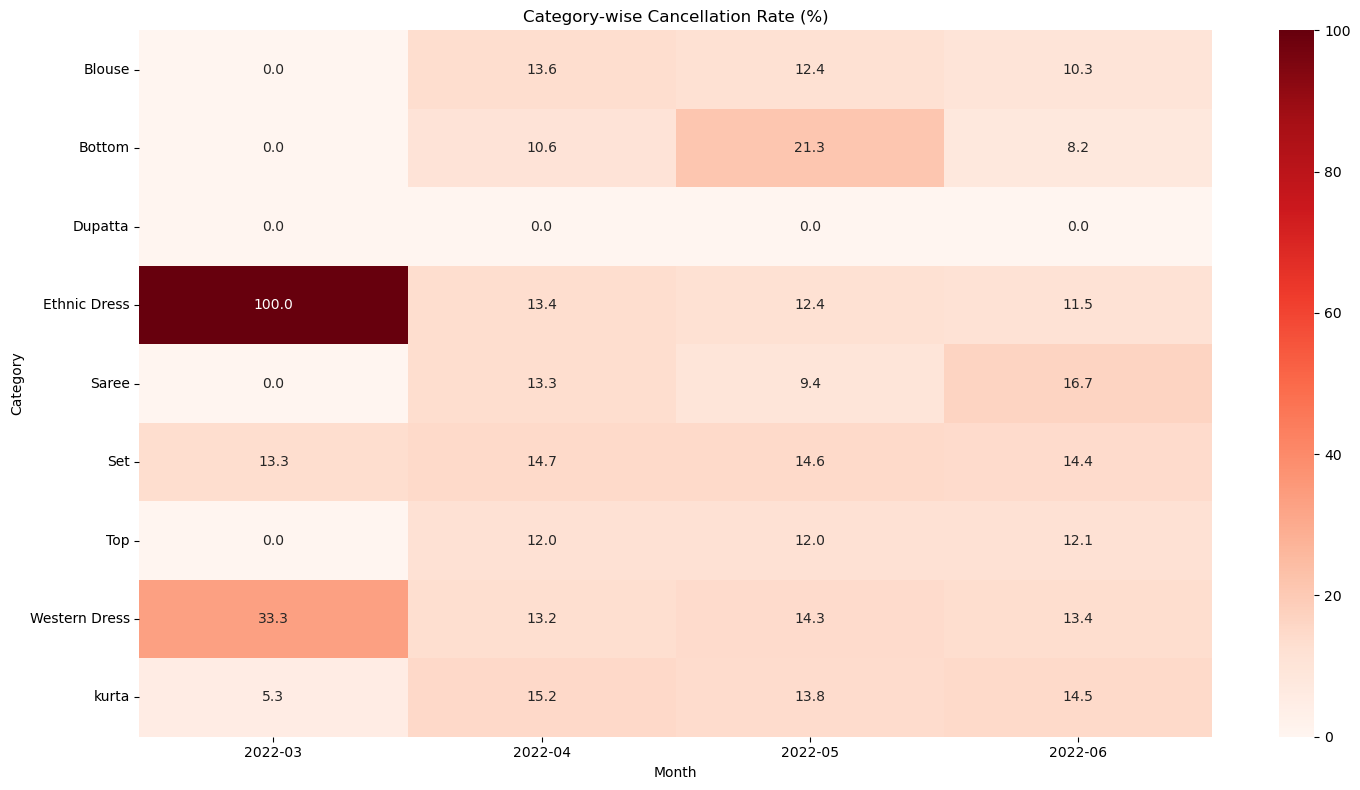

In [39]:
plt.figure(figsize=(15,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="Reds",
    fmt=".1f"
)

plt.title("Category-wise Cancellation Rate (%)")

plt.xlabel("Month")

plt.ylabel("Category")

plt.tight_layout()

plt.show()